# ITRF to GCRF coordinate transformation

## Load data from CSV

In this cell:

- **select the dataset** by three parameters:
  - `TECHNIQUE` (e.g. orbits),
  - `SOLUTION` (e.g. ssa),
  - `SATELLITE` (e.g. top),

- **build paths** to the project directory and to the `exports` folder where the resulting CSV file is stored,

- **verify that the folder and file exist** (to avoid cryptic errors later in the pipeline),

- **load the CSV into `df`** and immediately convert time columns to `datetime`, if present:
  - `epoch_UTC` (time in UTC),
  - `epoch` (time in TAI / original epoch, if stored as text).

The result is a DataFrame `df` containing timestamps, coordinates (x, y, z) and velocities (vx, vy, vz) in ITRF/ITRS, plus auxiliary time columns (MJD_TAI, MJD_UTC, leap_seconds...).

In [1]:
from pathlib import Path
import pandas as pd

# --- Dataset selection + path setup (CSV in exports) ---

TECHNIQUE = "orbits"
SOLUTION  = "ssa"
SATELLITE = "ja3"#"gope"#"swo"

PROJECT_ROOT = Path(r"C:\Users\michal\Desktop\Drahy_druzic")
OUTPUT_ROOT  = PROJECT_ROOT / "data"

DATA_DIR   = OUTPUT_ROOT / TECHNIQUE / SOLUTION.lower().strip() / SATELLITE.lower().strip()
EXPORT_DIR = DATA_DIR / "exports"

# name of the CSV file saved earlier
CSV_FILE = "ssaswo20_b23015_e23022_DG_.csv"
CSV_FILE = "GOP_cs2_250101_250101_V99.csv"
CSV_FILE = "ssaja320_b22008_e22018_DG_.csv"
CSV_FILE = "GOP_ja3_240820_240820_V99.csv"
CSV_FILE = "ssaja320_b24232_e24241_DG.csv"

CSV_PATH = EXPORT_DIR / CSV_FILE

print("📁 PROJECT_ROOT:", PROJECT_ROOT)
print("📁 DATA_DIR:    ", DATA_DIR)
print("📤 EXPORT_DIR:  ", EXPORT_DIR)
print("📄 CSV_PATH:    ", CSV_PATH)

if not EXPORT_DIR.exists():
    raise FileNotFoundError(f"EXPORT_DIR neexistuje: {EXPORT_DIR}")

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV soubor neexistuje: {CSV_PATH}")

# load
df = pd.read_csv(CSV_PATH)

# convert epoch_UTC to datetime if present
if "epoch_UTC" in df.columns:
    df["epoch_UTC"] = pd.to_datetime(df["epoch_UTC"])

# also convert epoch (TAI) if still stored as text
if "epoch" in df.columns:
    df["epoch"] = pd.to_datetime(df["epoch"])

print("✅ Načteno:", df.shape)
df.head(10)

📁 PROJECT_ROOT: C:\Users\michal\Desktop\Drahy_druzic
📁 DATA_DIR:     C:\Users\michal\Desktop\Drahy_druzic\data\orbits\ssa\ja3
📤 EXPORT_DIR:   C:\Users\michal\Desktop\Drahy_druzic\data\orbits\ssa\ja3\exports
📄 CSV_PATH:     C:\Users\michal\Desktop\Drahy_druzic\data\orbits\ssa\ja3\exports\ssaja320_b24232_e24241_DG.csv
✅ Načteno: (14308, 11)


,epoch,x,y,z,vx,vy,vz,MJD_TAI,leap_seconds,MJD_UTC,epoch_UTC
0,2024-08-19 00:25:00,3512766.290,-1222113.963,-6760786.654,-1299.629775,6575.240812,-1863.069920,60541.017361,37,60541.016933,2024-08-19 00:24:23
1,2024-08-19 00:26:00,3431127.272,-825560.856,-6861967.689,-1420.871204,6639.963427,-1508.761044,60541.018056,37,60541.017627,2024-08-19 00:25:23
2,2024-08-19 00:27:00,3342359.652,-425708.464,-6941744.587,-1537.217877,6685.182372,-1149.783047,60541.018750,37,60541.018322,2024-08-19 00:26:23
3,2024-08-19 00:28:00,3246762.703,-23732.660,-6999870.515,-1648.486291,6710.718807,-787.248363,60541.019444,37,60541.019016,2024-08-19 00:27:23
4,2024-08-19 00:29:00,3144646.206,379181.684,-7036165.705,-1754.509825,6716.451758,-422.279617,60541.020139,37,60541.019711,2024-08-19 00:28:23
5,2024-08-19 00:30:00,3036329.430,781844.189,-7050517.978,-1855.138618,6702.318584,-56.006451,60541.020833,37,60541.020405,2024-08-19 00:29:23
6,2024-08-19 00:31:00,2922140.142,1183062.473,-7042883.059,-1950.239434,6668.315325,310.437717,60541.021528,37,60541.021100,2024-08-19 00:30:23
7,2024-08-19 00:32:00,2802413.604,1581645.684,-7013284.711,-2039.695506,6614.496864,675.918996,60541.022222,37,60541.021794,2024-08-19 00:31:23
8,2024-08-19 00:33:00,2677491.598,1976408.027,-6961814.663,-2123.406288,6540.976902,1039.306288,60541.022917,37,60541.022488,2024-08-19 00:32:23
9,2024-08-19 00:34:00,2547721.458,2366172.291,-6888632.344,-2201.287155,6447.927839,1399.474496,60541.023611,37,60541.023183,2024-08-19 00:33:23


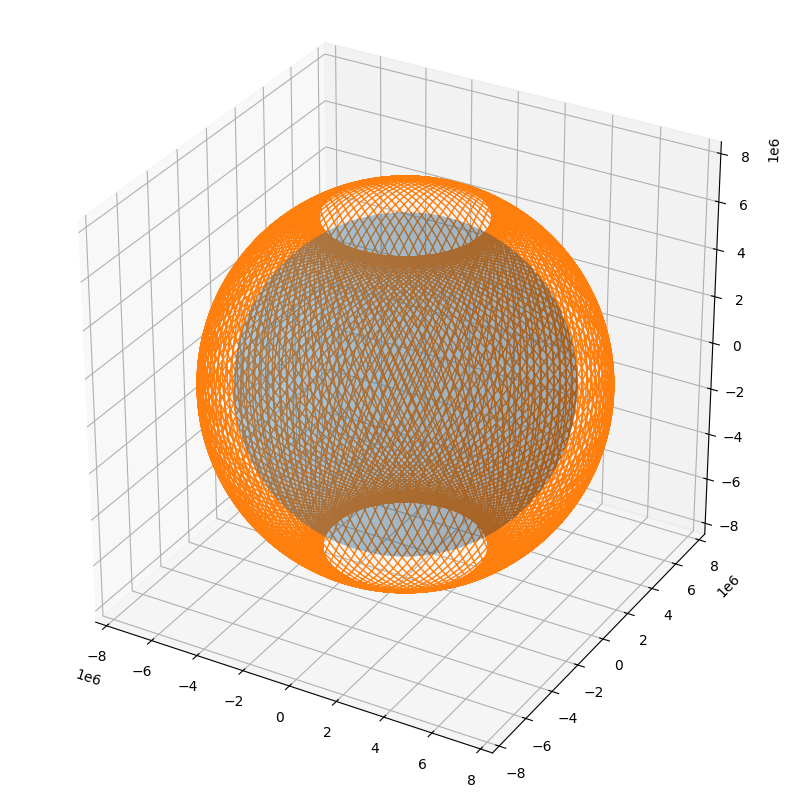

✅ Uloženo: orbit_itrs.pdf


<Figure size 640x480 with 0 Axes>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Settings ---
R = 6_378_000  # m
Pdf_PATH = "orbit_itrs.pdf"  # kam uložit

# -------- data (ITRS) --------
x = df["x"].to_numpy(float)
y = df["y"].to_numpy(float)
z = df["z"].to_numpy(float)

m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
x, y, z = x[m], y[m], z[m]

# downsample to keep PDF size manageable
N = len(x)
step = max(1, N // 8000)
x, y, z = x[::step], y[::step], z[::step]

# --- Earth sphere ---
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, np.pi, 50)
Xs = R * np.outer(np.cos(u), np.sin(v))
Ys = R * np.outer(np.sin(u), np.sin(v))
Zs = R * np.outer(np.ones_like(u), np.cos(v))

# -------- plot --------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Xs, Ys, Zs, alpha=0.2, linewidth=0)
ax.plot(x, y, z, lw=1.0)

# equal axis scale
max_range = max(np.ptp(x), np.ptp(y), np.ptp(z), 2*R)
cx, cy, cz = (x.min()+x.max())/2, (y.min()+y.max())/2, (z.min()+z.max())/2
half = 0.55 * max_range

ax.set_xlim(cx-half, cx+half)
ax.set_ylim(cy-half, cy+half)
ax.set_zlim(cz-half, cz+half)

# cubic bounding box (when Matplotlib supports it)
if hasattr(ax, "set_box_aspect"):
    ax.set_box_aspect([1, 1, 1])

# save to PDF
plt.tight_layout()
plt.show()
plt.savefig(Pdf_PATH, format="pdf")
plt.close(fig)

print("✅ Uloženo:", Pdf_PATH)

In [3]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import IFrame, display

# --- Settings ---
R = 6_378_000  # m
Html_PATH = "orbit_itrs.html"

# (A) renderer for notebook display:
# - "notebook_connected" = most reliable in classic Jupyter Notebook
# - "jupyterlab" = for JupyterLab (sometimes)
# - "iframe" = works almost always (renders as embedded HTML)
pio.renderers.default = "iframe"

# -------- data (ITRS) --------
x = df["x"].to_numpy(float)
y = df["y"].to_numpy(float)
z = df["z"].to_numpy(float)

m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
x, y, z = x[m], y[m], z[m]

# downsample
N = len(x)
step = max(1, N // 8000)
x, y, z = x[::step], y[::step], z[::step]

# --- Earth sphere ---
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, np.pi, 50)
Xs = R * np.outer(np.cos(u), np.sin(v))
Ys = R * np.outer(np.sin(u), np.sin(v))
Zs = R * np.outer(np.ones_like(u), np.cos(v))

# -------- plot --------
fig = go.Figure([
    go.Surface(x=Xs, y=Ys, z=Zs, opacity=0.2, showscale=False),
    go.Scatter3d(x=x, y=y, z=z, mode="lines", line=dict(width=3))
])

max_range = max(np.ptp(x), np.ptp(y), np.ptp(z), 2*R)
cx, cy, cz = (x.min()+x.max())/2, (y.min()+y.max())/2, (z.min()+z.max())/2
half = 0.55 * max_range

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[cx-half, cx+half]),
        yaxis=dict(range=[cy-half, cy+half]),
        zaxis=dict(range=[cz-half, cz+half]),
        aspectmode="cube"
    ),
    width=900, height=900
)

# --- Save and display reliably ---
fig.write_html(Html_PATH, include_plotlyjs=True)
print("✅ Uloženo:", Html_PATH)

# display directly in notebook as iframe
display(IFrame(Html_PATH, width=950, height=950))

✅ Uloženo: orbit_itrs.html


## Convert from ITRS to GCRS

The input data (CSV) contains satellite position and velocity in the **ITRS**
(*International Terrestrial Reference System*), i.e. in the Earth-fixed frame.

For further analysis we need to transform to an **inertial geocentric frame**, specifically **GCRS** (*Geocentric Celestial Reference System*).

The **GCRS** frame:
- has its **origin at the Earth’s centre of mass (geocentre)**,
- is **inertial** (does not rotate with the Earth),
- its axes **do not rotate with respect to ICRS**.

---

## Time scales required for the transformation

The ITRS-to-GCRS transformation depends on the precise orientation and rotation of the Earth at a given time. Several time scales are therefore needed; Astropy handles them automatically.

### 1) TAI — International Atomic Time
- Stable atomic time scale.
- Used in this project as the **input time scale** (`MJD_TAI`).
- Suitable for numerical processing of long time series.

### 2) TT — Terrestrial Time
- Used for **precession and nutation** calculations.
- Derived from TAI by:

$$
TT = TAI + 32.184\ \text{s}
$$

### 3) UT1
- Represents the **actual rotation of the Earth**.
- Differs from UTC by an irregular correction $UT1 - UTC$.
- Required for computing the **Earth Rotation Angle (ERA)**.

The time `Time(..., scale="tai")` is automatically converted by Astropy to the necessary scales using **IERS tables**.

📘 Astropy time scales documentation: https://docs.astropy.org/en/stable/time/

---

## Coordinate and velocity transformation

The **ITRS → GCRS** conversion follows the **IAU** and **IERS** recommendations and can be broken down into several steps.

### 1) Polar motion
Small rotations around the $X$ and $Y$ axes describing the displacement of the Earth’s rotation axis relative to the crust.

Parameters:
- $x_p$, $y_p$ (Earth Orientation Parameters from IERS)

Polar motion matrix:
$$
R_{\text{pole}} = R_x(y_p)\,R_y(x_p)
$$

### 2) Earth rotation (Earth Rotation Angle)
Rotation around the $Z$ axis describing the Earth’s daily rotation, depending on UT1:

$$
R_{\text{ERA}} = R_z(-\theta_{\text{ERA}})
$$

where $\theta_{\text{ERA}}$ is the **Earth Rotation Angle**.

### 3) Precession and nutation
- **Precession**: long-term change in the orientation of the Earth’s axis.
- **Nutation**: short-term periodic oscillations of the axis.

These effects are described by a combination of the precession and nutation matrices:

$$
R_{\text{PN}} = P \cdot N
$$

(specific models per IAU 2000/2006).

### 4) Position transformation result
The total position transformation can be written schematically as:

$$
\mathbf{r}_{\text{GCRS}} =
R_{\text{PN}} \cdot
R_{\text{ERA}} \cdot
R_{\text{pole}} \cdot
\mathbf{r}_{\text{ITRS}}
$$

### 5) Velocity transformation
Velocities cannot be transformed with the same matrix as positions, because
ITRS is a **rotating frame**.

The velocity transformation has the form:

$$
\mathbf{v}_{\text{GCRS}} = R\,\mathbf{v}_{\text{ITRS}} + \boldsymbol{\omega}_{\oplus} \times \mathbf{r}_{\text{GCRS}}
$$

where:
- $\boldsymbol{\omega}_{\oplus}$ is the Earth’s angular rotation rate,
- the second term represents the effect of the rotating frame.

Astropy handles this term automatically using **differentials**.

---

## What Astropy does internally

When calling:

```python
ITRS(...).transform_to(GCRS(obstime=t))
```

Astropy performs the following steps:

- uses the given time `obstime` and converts it to the necessary time scales
  (especially TT and UT1),
- loads **Earth Orientation Parameters (EOP)** from IERS tables,
- applies:
  - polar motion,
  - Earth rotation (Earth Rotation Angle),
  - precession and nutation transformation,
- performs the correct transformation of **position and velocity** between frames,
  accounting for the Earth’s rotation in the velocity transformation.

The procedure follows **IAU/IERS** recommendations and is implemented transparently in Astropy via a transformation graph between reference frames. The user does not need to manually implement any rotation matrices or time corrections.

📘 **Astropy documentation**

- [Reference frames and transformations (frames)](https://docs.astropy.org/en/stable/coordinates/frames.html)
- [ITRS — International Terrestrial Reference System](https://docs.astropy.org/en/stable/api/astropy.coordinates.ITRS.html)
- [GCRS — Geocentric Celestial Reference System](https://docs.astropy.org/en/stable/api/astropy.coordinates.GCRS.html)
- [Velocities and differentials in Astropy](https://docs.astropy.org/en/stable/coordinates/velocities.html)

In [4]:
import numpy as np
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import ITRS, GCRS

t = Time(df["MJD_TAI"].values, format="mjd", scale="tai")

g = ITRS(
    x=df["x"].values*u.m, y=df["y"].values*u.m, z=df["z"].values*u.m,
    v_x=df["vx"].values*(u.m/u.s), v_y=df["vy"].values*(u.m/u.s), v_z=df["vz"].values*(u.m/u.s),
    obstime=t
).transform_to(GCRS(obstime=t))

r_gcrs = g.cartesian.xyz.to_value(u.m).T
v_gcrs = g.velocity.d_xyz.to_value(u.m/u.s).T

In [5]:
r_gcrs

array([[ 2588446.85333382, -2655277.94457221, -6766887.58973866],
       [ 2701044.08070974, -2251855.50446041, -6868354.48339672],
       [ 2805235.00849418, -1841424.5324101 , -6948397.361215  ],
       ...,
       [ 4594425.096277  ,  5619073.82737457, -2624412.39175694],
       [ 4527695.7263198 ,  5830004.95485125, -2254324.92614019],
       [ 4446830.38136022,  6022734.34352834, -1877183.84463206]],
      shape=(14308, 3))

In [6]:
v_gcrs

array([[ 1944.76661724,  6658.28922066, -1867.9950417 ],
       [ 1807.50318227,  6785.63400404, -1513.36207878],
       [ 1664.62897759,  6891.84754835, -1154.04571154],
       ...,
       [ -993.14888216,  3663.60459606,  6102.88362456],
       [-1230.59066247,  3365.59604951,  6230.15104273],
       [-1464.224609  ,  3057.03817418,  6337.94160215]], shape=(14308, 3))

In [7]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# df in GCRS/GCRF (position + velocity) — new dataframe
# ------------------------------------------------------------

# r_gcrs and v_gcrs are Nx3 (from the previous cell)
# r_gcrs[:,0]=X, r_gcrs[:,1]=Y, r_gcrs[:,2]=Z
# v_gcrs[:,0]=VX, v_gcrs[:,1]=VY, v_gcrs[:,2]=VZ

df_gcrs = pd.DataFrame({
    # keep original epochs (MJD_TAI) — ground truth
    "MJD_TAI": df["MJD_TAI"].to_numpy(float),

    # GCRF/GCRS coordinates in metres
    "x": r_gcrs[:, 0],
    "y": r_gcrs[:, 1],
    "z": r_gcrs[:, 2],

    # GCRF/GCRS rychlosti v m/s
    "vx": v_gcrs[:, 0],
    "vy": v_gcrs[:, 1],
    "vz": v_gcrs[:, 2],
})

print("✅ df_gcrs:", df_gcrs.shape)
df_gcrs.head(10)

✅ df_gcrs: (14308, 7)


,MJD_TAI,x,y,z,vx,vy,vz
0,60541.017361,2.588447e+06,-2.655278e+06,-6.766888e+06,1944.766617,6658.289221,-1867.995042
1,60541.018056,2.701044e+06,-2.251856e+06,-6.868354e+06,1807.503182,6785.634004,-1513.362079
2,60541.018750,2.805235e+06,-1.841425e+06,-6.948397e+06,1664.628978,6891.847548,-1154.045712
3,60541.019444,2.900696e+06,-1.425263e+06,-7.006769e+06,1516.586377,6976.605757,-791.159423
4,60541.020139,2.987131e+06,-1.004666e+06,-7.043288e+06,1363.833242,7039.649880,-425.826925
5,60541.020833,3.064271e+06,-5.809431e+05,-7.057841e+06,1206.841616,7080.787205,-59.178984
6,60541.021528,3.131877e+06,-1.554124e+05,-7.050385e+06,1046.096367,7099.891619,307.649824
7,60541.022222,3.189738e+06,2.706020e+05,-7.020943e+06,882.093748,7096.903977,673.524422
8,60541.022917,3.237673e+06,6.957743e+05,-6.969604e+06,715.339972,7071.832244,1037.312496
9,60541.023611,3.275534e+06,1.118782e+06,-6.896529e+06,546.349792,7024.751513,1397.887714


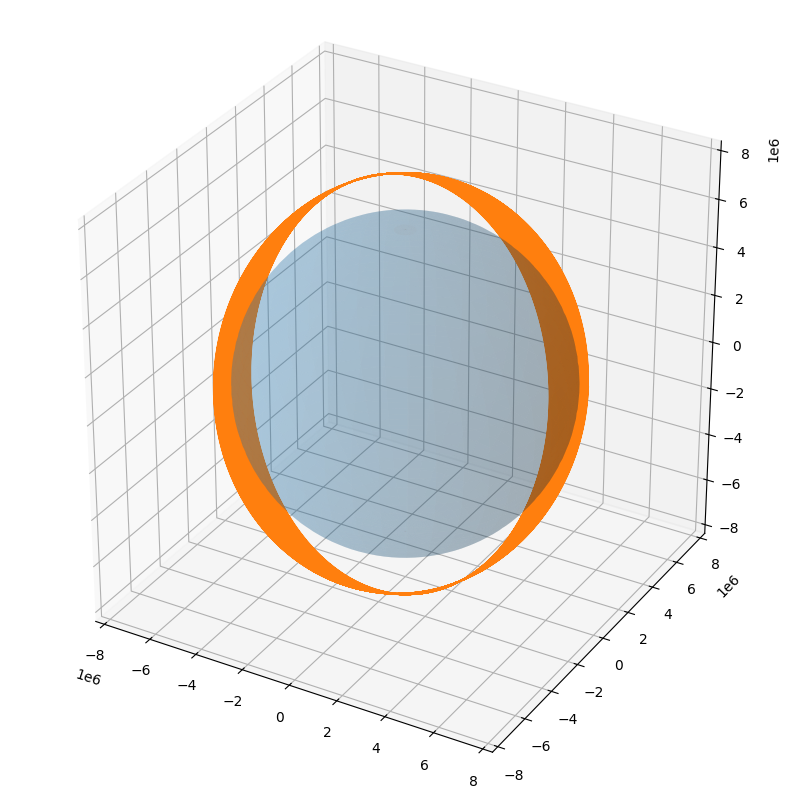

✅ Uloženo: orbit_gcrs.pdf


<Figure size 640x480 with 0 Axes>

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Settings ---
R = 6_378_000  # m
Pdf_PATH = "orbit_gcrs.pdf"  # kam uložit

# -------- data (ITRS) --------
x = df_gcrs["x"].to_numpy(float)
y = df_gcrs["y"].to_numpy(float)
z = df_gcrs["z"].to_numpy(float)

m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
x, y, z = x[m], y[m], z[m]

# downsample to keep PDF size manageable
N = len(x)
step = max(1, N // 8000)
x, y, z = x[::step], y[::step], z[::step]

# --- Earth sphere ---
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, np.pi, 50)
Xs = R * np.outer(np.cos(u), np.sin(v))
Ys = R * np.outer(np.sin(u), np.sin(v))
Zs = R * np.outer(np.ones_like(u), np.cos(v))

# -------- plot --------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Xs, Ys, Zs, alpha=0.2, linewidth=0)
ax.plot(x, y, z, lw=1.0)

# equal axis scale
max_range = max(np.ptp(x), np.ptp(y), np.ptp(z), 2*R)
cx, cy, cz = (x.min()+x.max())/2, (y.min()+y.max())/2, (z.min()+z.max())/2
half = 0.55 * max_range

ax.set_xlim(cx-half, cx+half)
ax.set_ylim(cy-half, cy+half)
ax.set_zlim(cz-half, cz+half)

# cubic bounding box (when Matplotlib supports it)
if hasattr(ax, "set_box_aspect"):
    ax.set_box_aspect([1, 1, 1])

# save to PDF
plt.tight_layout()
plt.show()
plt.savefig(Pdf_PATH, format="pdf")
plt.close(fig)

print("✅ Uloženo:", Pdf_PATH)

In [9]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import IFrame, display

# --- Settings ---
R = 6_378_000  # m
Html_PATH = "orbit_gcrs.html"

# (A) renderer for notebook display:
# - "notebook_connected" = most reliable in classic Jupyter Notebook
# - "jupyterlab" = for JupyterLab (sometimes)
# - "iframe" = works almost always (renders as embedded HTML)
pio.renderers.default = "iframe"

# -------- data (ITRS) --------
x = df_gcrs["x"].to_numpy(float)
y = df_gcrs["y"].to_numpy(float)
z = df_gcrs["z"].to_numpy(float)

m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
x, y, z = x[m], y[m], z[m]

# downsample
N = len(x)
step = max(1, N // 8000)
x, y, z = x[::step], y[::step], z[::step]

# --- Earth sphere ---
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, np.pi, 50)
Xs = R * np.outer(np.cos(u), np.sin(v))
Ys = R * np.outer(np.sin(u), np.sin(v))
Zs = R * np.outer(np.ones_like(u), np.cos(v))

# -------- plot --------
fig = go.Figure([
    go.Surface(x=Xs, y=Ys, z=Zs, opacity=0.2, showscale=False),
    go.Scatter3d(x=x, y=y, z=z, mode="lines", line=dict(width=3))
])

max_range = max(np.ptp(x), np.ptp(y), np.ptp(z), 2*R)
cx, cy, cz = (x.min()+x.max())/2, (y.min()+y.max())/2, (z.min()+z.max())/2
half = 0.55 * max_range

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[cx-half, cx+half]),
        yaxis=dict(range=[cy-half, cy+half]),
        zaxis=dict(range=[cz-half, cz+half]),
        aspectmode="cube"
    ),
    width=900, height=900
)

# --- Save and display reliably ---
fig.write_html(Html_PATH, include_plotlyjs=True)
print("✅ Uloženo:", Html_PATH)

# display directly in notebook as iframe
display(IFrame(Html_PATH, width=950, height=950))

✅ Uloženo: orbit_gcrs.html


In [10]:
# --- new name: append _GCRS before the extension ---
src_name = Path(CSV_FILE)
GCRS_FILE = f"{src_name.stem}_GCRS{src_name.suffix}"   # -> ssaswo20_b23015_e23022_DG__GCRS.csv
GCRS_PATH = EXPORT_DIR / GCRS_FILE

# create export directory if it does not exist
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("📤 Ukládám do:", GCRS_PATH)

# save DataFrame
df_gcrs.to_csv(GCRS_PATH, index=False)

print("✅ Uloženo:", df_gcrs.shape)

📤 Ukládám do: C:\Users\michal\Desktop\Drahy_druzic\data\orbits\ssa\ja3\exports\ssaja320_b24232_e24241_DG_GCRS.csv
✅ Uloženo: (14308, 7)
